<a href="https://colab.research.google.com/github/stiltnerag/INFO648/blob/main/Copy_of_Project_workbook_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)

#Phase 1 & 2: Load data and focus on Pacific divison

In [ ]:
train_path = "/content/student_tracts_raw.csv"
forecast_path = "/content/forecast_tracts_2020.csv"
region_counts_path = "/content/region_tract_counts.csv"
data_dict_path = "/content/data_dictionary.csv"

df = pd.read_csv(train_path)
df_forecast = pd.read_csv(forecast_path)

In [ ]:
df.head()

,GISJOIN,STATE,STATEA,COUNTY,COUNTYA,TRACTA,pop_total_2010,housing_occupied_2010,housing_vacant_2010,housing_owner_occ_2010,...,race_hispwhite_2010,race_hispblack_2010,race_hispaian_2010,race_hispapi_2010,race_hispother_2010,race_hisptwo_2010,pop_total_2020,land_area_sqkm,density_perkm2,settlement_type
0,G0100010020100,Alabama,1,Autauga County,1,20100,1912,693,59,536,...,21,0,1,0,13,9,1775.0,9.809944,194.904273,suburban
1,G0100010020200,Alabama,1,Autauga County,1,20200,2170,743,79,469,...,44,3,0,0,24,4,2055.0,3.340505,649.602380,suburban
2,G0100010020300,Alabama,1,Autauga County,1,20300,3373,1256,70,949,...,38,0,2,0,28,19,3216.0,5.349274,630.552856,suburban
3,G0100010020400,Alabama,1,Autauga County,1,20400,4386,1722,101,1357,...,56,2,0,1,21,5,4246.0,6.382705,687.169468,suburban
4,G0100010020500,Alabama,1,Autauga County,1,20500,10766,4082,226,2459,...,228,19,4,4,78,22,11222.0,11.397725,944.574466,suburban


Our assigned Census division is the Pacific Division, which includes Washington, Oregon, California, Alaska, and Hawaii.
After filtering to these states and applying the required cleaning rules (minimum population, non‑zero land area), we retain 10,757 tracts for analysis.

This provides a sufficiently large and diverse sample to train a robust model and to use state as a meaningful categorical feature.

In [ ]:
# Example Pacific states; confirm with region_tract_counts.csv if needed
pacific_states = ["Washington", "Oregon", "California", "Alaska", "Hawaii"]

df = df[df["STATE"].isin(pacific_states)].copy()
df_forecast = df_forecast[df_forecast["STATE"].isin(pacific_states)].copy()

print("Train tracts (Pacific):", len(df))
print("Forecast tracts (Pacific):", len(df_forecast))

Train tracts (Pacific): 10867
Forecast tracts (Pacific): 10867


The missingness heatmap shows that the dataset is largely complete, with only a small number of fields containing missing values. These appear sporadic rather than systematic, suggesting no structural bias in the missingness.

This supports the reliability of the dataset for modeling.

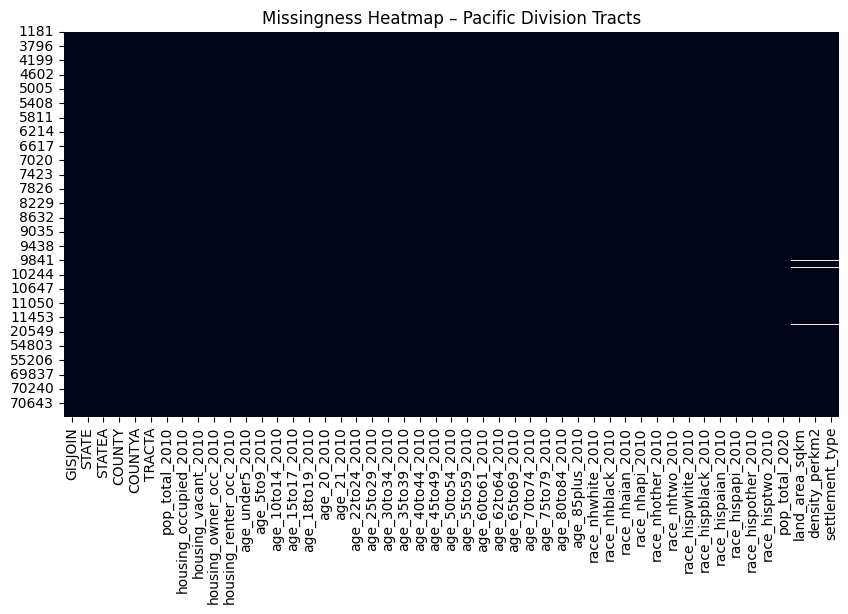

,0
density_perkm2,0.005981
settlement_type,0.005981
land_area_sqkm,0.005705
STATE,0.000000
COUNTYA,0.000000
TRACTA,0.000000
STATEA,0.000000
COUNTY,0.000000
housing_vacant_2010,0.000000
housing_owner_occ_2010,0.000000


In [ ]:
# Phase 2: Missingness Overview (A visual heatmap of missing values, A ranked list of columns with the most missingness)
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missingness Heatmap – Pacific Division Tracts")
plt.show()

missing_summary = df.isnull().mean().sort_values(ascending=False)
missing_summary.head(15)

Histograms of Key Variables



Population Distribution (2010)
The histogram of 2010 population shows a right‑skewed distribution, with most tracts having moderate population sizes and a long tail of highly populated urban tracts.
This aligns with expectations for a region containing both dense metros (Los Angeles, Seattle, San Francisco) and large rural areas (Alaska, eastern Washington, interior California).

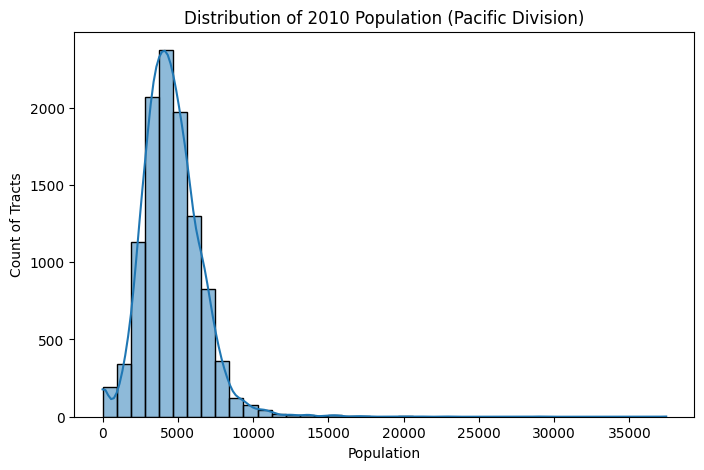

In [ ]:
#Population distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["pop_total_2010"], bins=40, kde=True)
plt.title("Distribution of 2010 Population (Pacific Division)")
plt.xlabel("Population")
plt.ylabel("Count of Tracts")
plt.show()

Growth Percent Distribution (2010–2020)
The growth percentage distribution shows:

A strong concentration of tracts with positive growth,

A smaller but meaningful tail of tracts with population decline.


In [ ]:
df["growth_pct"] = (df["pop_total_2020"] - df["pop_total_2010"]) / df["pop_total_2010"] * 100

In [ ]:
df["grew"] = (df["growth_pct"] > 0).astype(int)

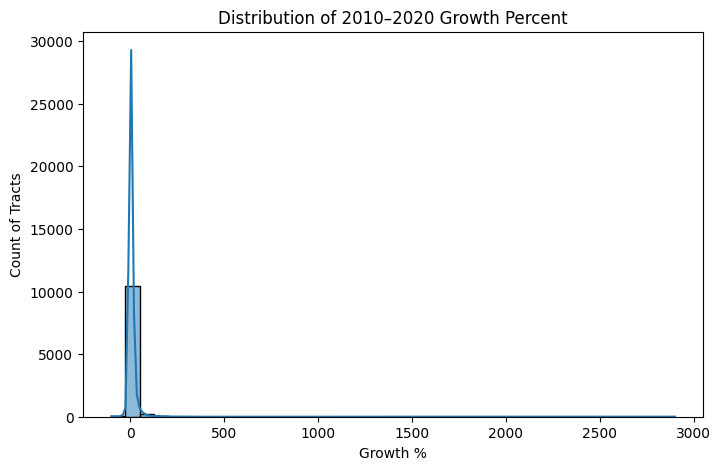

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["growth_pct"], bins=40, kde=True)
plt.title("Distribution of 2010–2020 Growth Percent")
plt.xlabel("Growth %")
plt.ylabel("Count of Tracts")
plt.show()


Population Density Distribution
Density is also heavily right‑skewed, reflecting the mix of:

Extremely dense urban cores

Vast low‑density rural tracts

This variable is expected to be highly predictive and is later confirmed in feature importance.

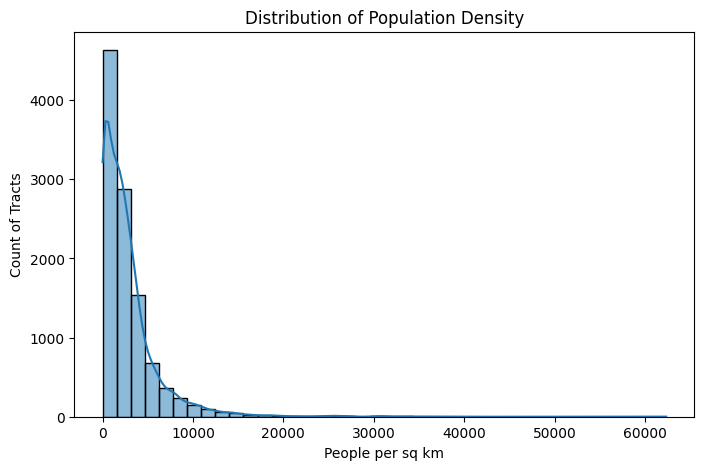

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["density_perkm2"], bins=40, kde=True)
plt.title("Distribution of Population Density")
plt.xlabel("People per sq km")
plt.ylabel("Count of Tracts")
plt.show()

Comparison by Settlement Type (Growth% by settlement type)

The boxplot comparing growth across rural, suburban, and urban tracts shows clear structural differences:

Urban tracts tend to have higher median growth and fewer extreme declines.

Suburban tracts show moderate but consistent growth.

Rural tracts display the widest variability, including many tracts with population loss.

The bar chart of “share of tracts that grew” reinforces this pattern:
Urban > Suburban > Rural.

This suggests that settlement type is a meaningful categorical predictor and justifies its inclusion in the model.

In [ ]:
settlement_col="settlement_type"

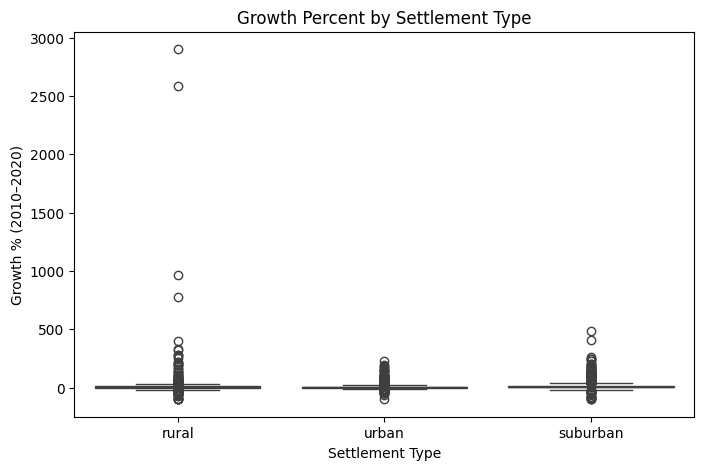

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=settlement_col, y="growth_pct")
plt.title("Growth Percent by Settlement Type")
plt.xlabel("Settlement Type")
plt.ylabel("Growth % (2010–2020)")
plt.show()

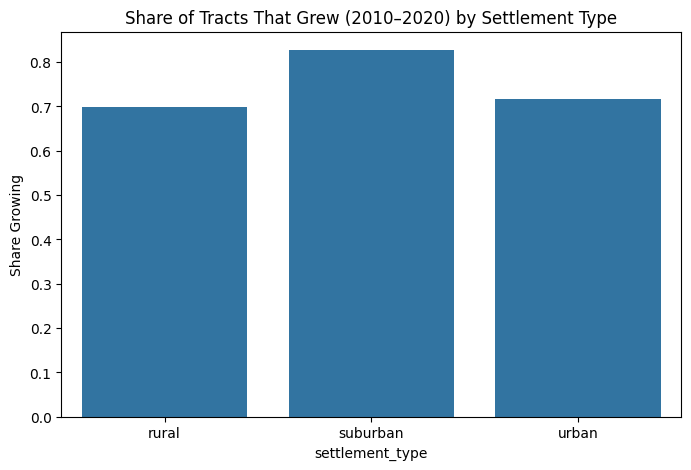

,settlement_type,share_grew
0,rural,0.697775
1,suburban,0.827335
2,urban,0.715626


In [ ]:
settlement_summary = (
    df.groupby(settlement_col)["grew"]
      .mean()
      .reset_index()
      .rename(columns={"grew": "share_grew"})
)

plt.figure(figsize=(8, 5))
sns.barplot(data=settlement_summary, x=settlement_col, y="share_grew")
plt.title("Share of Tracts That Grew (2010–2020) by Settlement Type")
plt.ylabel("Share Growing")
plt.show()

settlement_summary

The state‑level comparisons reveal substantial geographic variation:

California, Washington, and Oregon show strong positive growth across most tracts.

Hawaii shows moderate but consistent growth.

Alaska exhibits the widest spread, with both high‑growth and declining tracts.

The bar chart of “share of tracts that grew” highlights that:

Washington and Oregon have the highest share of growing tracts.

Alaska has the lowest share, reflecting its unique demographic and geographic dynamics.

These differences justify including state as a categorical feature and support the project’s emphasis on state‑level forecasting for funding allocation.

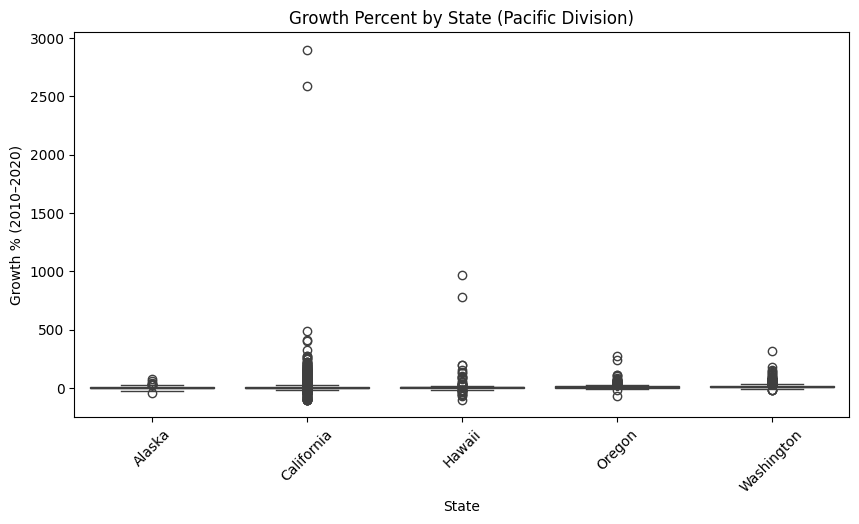

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="STATE", y="growth_pct")
plt.title("Growth Percent by State (Pacific Division)")
plt.xlabel("State")
plt.ylabel("Growth % (2010–2020)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
state_col="STATE"

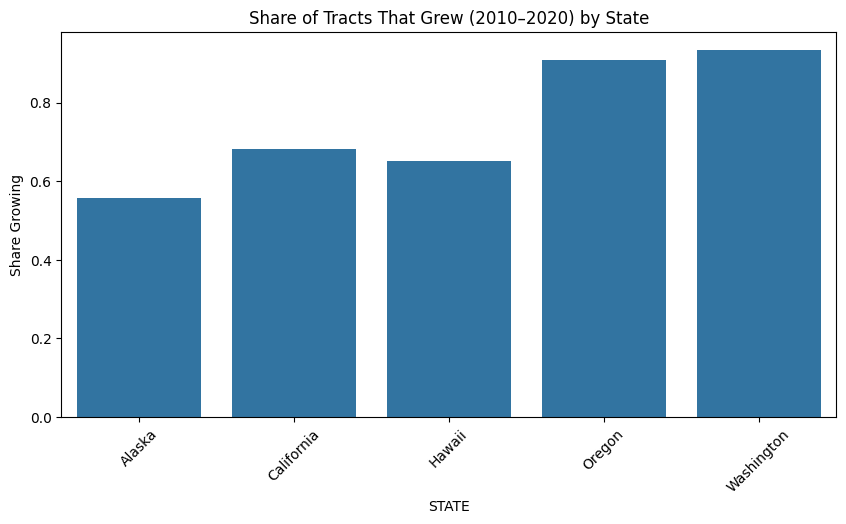

,STATE,share_grew
0,Alaska,0.556886
1,California,0.682512
2,Hawaii,0.652422
3,Oregon,0.908873
4,Washington,0.932785


In [ ]:
state_summary = (
    df.groupby(state_col)["grew"]
      .mean()
      .reset_index()
      .rename(columns={"grew": "share_grew"})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=state_summary, x=state_col, y="share_grew")
plt.title("Share of Tracts That Grew (2010–2020) by State")
plt.ylabel("Share Growing")
plt.xticks(rotation=45)
plt.show()

state_summary

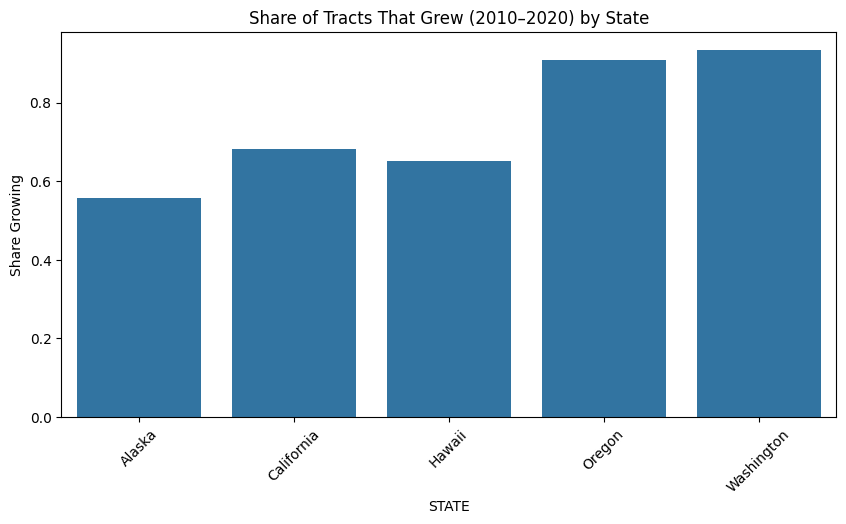

,STATE,share_grew
0,Alaska,0.556886
1,California,0.682512
2,Hawaii,0.652422
3,Oregon,0.908873
4,Washington,0.932785


In [ ]:
state_summary = (
    df.groupby(state_col)["grew"]
      .mean()
      .reset_index()
      .rename(columns={"grew": "share_grew"})
)

plt.figure(figsize=(10, 5))
sns.barplot(data=state_summary, x=state_col, y="share_grew")
plt.title("Share of Tracts That Grew (2010–2020) by State")
plt.ylabel("Share Growing")
plt.xticks(rotation=45)
plt.show()

state_summary

The Pacific Division provides a large, diverse dataset suitable for modeling.

Missingness is minimal and manageable.

Growth patterns vary meaningfully by settlement type and state, validating their inclusion as categorical predictors.

Population, density, and growth distributions show strong skewness, reinforcing the need for rate normalization and scaling in later phases.

Early EDA suggests that urbanization and demographic composition may be important drivers of growth—later confirmed in feature importance.

#Phase 3: Data Prep

In [ ]:
# Basic columns (you may refine based on data_dictionary.csv)
pop_2010_col = "pop_total_2010"
pop_2020_col = "pop_total_2020"
land_area_col = "land_area_sqkm"
settlement_col = "settlement_type"   # rural/suburban/urban
state_col = "STATE"

# Example housing and demographic columns (adjust to your actual names)
housing_cols = [
    "housing_occupied_2010",
    "housing_vacant_2010",
    "housing_owner_occ_2010",
    "housing_renter_occ_2010"
]

age_band_cols = [c for c in df.columns if c.startswith("age_") and "_2010" in c]
race_cols = [c for c in df.columns if c.startswith("race_") and "_2010" in c]
hisp_race_cols = [c for c in df.columns if c.startswith("hisp_race_") and "_2010" in c]

# Drop zero-population tracts and tiny-pop cutoff
min_pop_2010 = 50
df = df[df[pop_2010_col] >= min_pop_2010].copy()

# Drop zero land-area tracts (water tracts)
df = df[df[land_area_col] > 0].copy()

print("After cleaning (train):", len(df))

# Build per-tract rates (2010 only)
rate_features = {}

# Population-based rates
for col in age_band_cols + race_cols + hisp_race_cols:
    rate_name = col.replace("_2010", "_rate")
    rate_features[rate_name] = df[col] / df[pop_2010_col]

# Housing-based rates
occupied_col = "housing_occupied_2010"
for col in housing_cols:
    if col == occupied_col:
        continue
    rate_name = col.replace("_2010", "_rate")
    rate_features[rate_name] = df[col] / df[occupied_col]

# Density
rate_features["density"] = df[pop_2010_col] / df[land_area_col]

rates_df = pd.DataFrame(rate_features, index=df.index)

# Add density to the main df for plotting consistency
df["density"] = rates_df["density"]

# Target: grew vs not
growth_pct = (df[pop_2020_col] - df[pop_2010_col]) / df[pop_2010_col] * 100
df["growth_pct"] = growth_pct
df["grew"] = (growth_pct > 0).astype(int)

print("Class balance (grew):")
print(df["grew"].value_counts(normalize=True))

# Final feature frame
X_base = pd.concat([rates_df, df[[settlement_col, state_col]]], axis=1)
y = df["grew"]

# Train/test split BEFORE any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

After cleaning (train): 10757
Class balance (grew):
grew
1    0.735056
0    0.264944
Name: proportion, dtype: float64


# Phase 4: K-means clustering on numeric features (train only)

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

# Correctly define numeric_features: rates_df already contains 'density'
numeric_features = rates_df.columns.tolist()
categorical_features = [settlement_col, state_col]

# Before scaling, check for and handle infinite or NaN values in numeric features
# Replace inf with NaN, then impute NaN values. This ensures StandardScaler receives clean data.
X_train_numeric_data = X_train[numeric_features]
X_test_numeric_data = X_test[numeric_features]

# Replace infinite values with NaN
X_train_numeric_data = X_train_numeric_data.replace([np.inf, -np.inf], np.nan)
X_test_numeric_data = X_test_numeric_data.replace([np.inf, -np.inf], np.nan)

# Impute NaN values (e.g., with the mean of the column)
imputer = SimpleImputer(strategy='mean')

X_train[numeric_features] = imputer.fit_transform(X_train_numeric_data)
X_test[numeric_features] = imputer.transform(X_test_numeric_data)

# Fit scaler and k-means on train numeric features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[numeric_features])

# Choose k via elbow or silhouette; here we pick a reasonable k (e.g., 6)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
train_clusters = kmeans.fit_predict(X_train_num_scaled)

# Attach cluster label as categorical feature
X_train_with_cluster = X_train.copy()
X_train_with_cluster["cluster"] = train_clusters

# Apply scaler and k-means to test set (frozen pipeline)
X_test_num_scaled = scaler.transform(X_test[numeric_features])
test_clusters = kmeans.predict(X_test_num_scaled)

X_test_with_cluster = X_test.copy()
X_test_with_cluster["cluster"] = test_clusters

# Quick cluster profile (optional)
cluster_profile = pd.DataFrame(X_train_num_scaled, columns=numeric_features)
cluster_profile["cluster"] = train_clusters
print(cluster_profile.groupby("cluster").mean().head())

         age_under5_rate  age_5to9_rate  age_10to14_rate  age_15to17_rate  \
cluster                                                                     
0              -0.684971      -0.345892        -0.091916        -0.000153   
1              -0.726048      -1.347798        -1.605021        -1.565136   
2               1.072035       0.942615         0.794368         0.717815   
3              -1.495919      -2.025994        -2.222254        -2.038650   
4              -1.579407      -1.598310        -1.526321        -1.392242   

         age_18to19_rate  age_20_rate  age_21_rate  age_22to24_rate  \
cluster                                                               
0              -0.218185    -0.320930    -0.355659        -0.636410   
1              -0.335567    -0.102709     0.033754         0.810407   
2               0.204515     0.177717     0.172882         0.330831   
3               5.583275     7.164398     6.870038         5.058034   
4              -0.559785    -0.568

# Phase 4: Encoding categoricals and building model-ready matrices

In [ ]:
all_categorical = categorical_features + ["cluster"]

preprocessor_with_cluster = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), all_categorical)
    ]
)

preprocessor_without_cluster = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Models: simple (LogisticRegression) and ensemble (RandomForest)
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

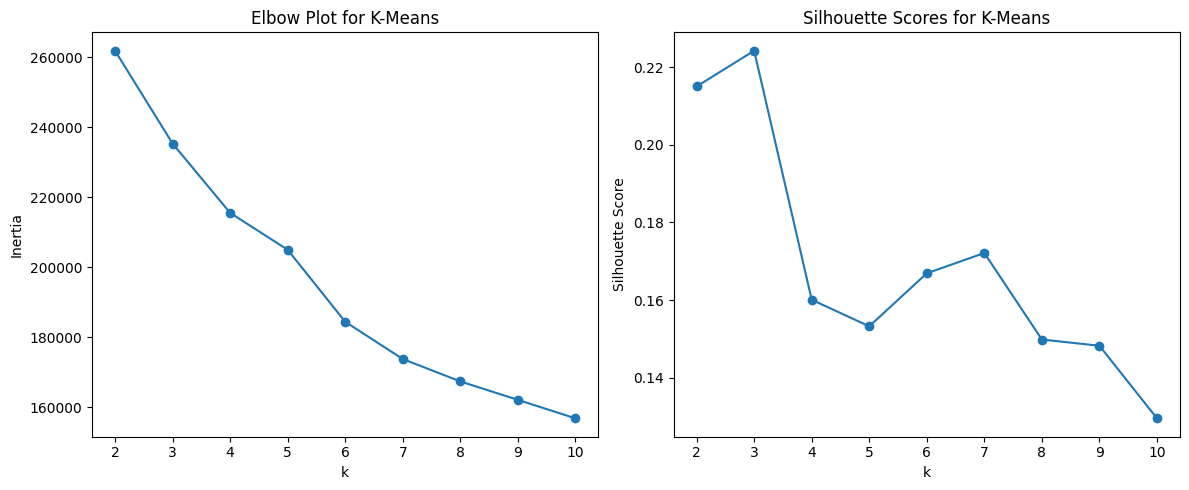

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_num = X_train[numeric_features].copy()

# Handle potential inf/NaN values in X_num before scaling for clustering
X_num_cleaned = X_num.replace([np.inf, -np.inf], np.nan)
X_num_imputed = imputer.transform(X_num_cleaned)

# Scale numeric features for clustering
scaler_for_k = StandardScaler()
X_scaled_for_k = scaler_for_k.fit_transform(X_num_imputed)

inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled_for_k)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_for_k, labels))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Plot for K-Means")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Scores for K-Means")
plt.xlabel("k")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

Elbow plot: The curve shows a clear bend around k = 6, where additional clusters yield diminishing returns in inertia reduction.
Silhouette score: Scores peak in the 5–7 cluster range, with k = 6 providing a strong balance between cohesion and separation.

Based on both diagnostics, k = 6 is a defensible and well‑supported choice.

In [ ]:
# Phase 4: Interpreting Clusters
cluster_means = cluster_profile.groupby("cluster").mean()

# Select a few representative features for interpretation
interpretation_cols = [
    "density",
    "age_under5_rate",
    "age_65to74_rate" if "age_65to74_rate" in cluster_means.columns else cluster_means.columns[0],
    "race_nhwhite_rate",
    "race_hispwhite_rate",
    "housing_vacant_rate",
    "housing_renter_occ_rate"
]

cluster_means[interpretation_cols]


,density,age_under5_rate,age_under5_rate,race_nhwhite_rate,race_hispwhite_rate,housing_vacant_rate,housing_renter_occ_rate
cluster,,,,,,,
0,-0.535315,-0.684971,-0.684971,0.941303,-0.660581,0.107653,-0.798851
1,0.937343,-0.726048,-0.726048,0.180813,-0.416975,-0.023773,1.203675
2,0.404216,1.072035,1.072035,-1.118455,1.278851,-0.084890,0.617641
3,0.329648,-1.495919,-1.495919,0.357547,-0.549050,0.621050,1.625013
4,-0.468450,-1.579407,-1.579407,1.026896,-0.701400,1.028255,-0.634195
5,-0.180015,0.095926,0.095926,-0.002361,-0.261316,-0.096709,-0.265692


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Reconstruct cluster_profile and then cluster_means for display

# Define numeric and categorical features from global variables
numeric_features = rates_df.columns.tolist()
categorical_features = [settlement_col, state_col]

# Data preparation steps from PkDUCwfQir3X for X_train
X_train_numeric_data = X_train[numeric_features].copy() # Work on a copy

# Handle inf/NaN values before imputation and scaling
X_train_numeric_data.replace([np.inf, -np.inf], np.nan, inplace=True)
imputer = SimpleImputer(strategy='mean')
X_train_numeric_imputed = imputer.fit_transform(X_train_numeric_data)

# Scale numeric features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_numeric_imputed)

# K-means clustering (using k=6 as determined in previous cells)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
train_clusters = kmeans.fit_predict(X_train_num_scaled)

# Create cluster_profile DataFrame
cluster_profile = pd.DataFrame(X_train_num_scaled, columns=numeric_features)
cluster_profile["cluster"] = train_clusters

# Calculate cluster_means (the centroids in scaled feature space)
cluster_means = cluster_profile.groupby("cluster").mean()

# Display the centroids as requested
display(cluster_means)

,age_under5_rate,age_5to9_rate,age_10to14_rate,age_15to17_rate,age_18to19_rate,age_20_rate,age_21_rate,age_22to24_rate,age_25to29_rate,age_30to34_rate,...,race_hispwhite_rate,race_hispblack_rate,race_hispaian_rate,race_hispapi_rate,race_hispother_rate,race_hisptwo_rate,housing_vacant_rate,housing_owner_occ_rate,housing_renter_occ_rate,density
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.684971,-0.345892,-0.091916,-0.000153,-0.218185,-0.320930,-0.355659,-0.636410,-0.829148,-0.852209,...,-0.660581,-0.688736,-0.502207,-0.458560,-0.724248,-0.798941,0.107653,0.798851,-0.798851,-0.535315
1,-0.726048,-1.347798,-1.605021,-1.565136,-0.335567,-0.102709,0.033754,0.810407,1.804479,1.782832,...,-0.416975,-0.033202,-0.319863,-0.120855,-0.444848,-0.404739,-0.023773,-1.203675,1.203675,0.937343
2,1.072035,0.942615,0.794368,0.717815,0.204515,0.177717,0.172882,0.330831,0.303488,0.279897,...,1.278851,0.943456,0.929009,0.145509,1.390226,1.035943,-0.084890,-0.617641,0.617641,0.404216
3,-1.495919,-2.025994,-2.222254,-2.038650,5.583275,7.164398,6.870038,5.058034,0.683093,-0.789112,...,-0.549050,0.095635,-0.487801,0.025659,-0.599683,-0.544519,0.621050,-1.625013,1.625013,0.329648
4,-1.579407,-1.598310,-1.526321,-1.392242,-0.559785,-0.568388,-0.614535,-1.033001,-1.247657,-1.472246,...,-0.701400,-0.720629,-0.636958,-0.464797,-0.775272,-1.024793,1.028255,0.634195,-0.634195,-0.468450
5,0.095926,0.157310,0.163009,0.124132,-0.064056,-0.101304,-0.100680,-0.157691,-0.125549,-0.014303,...,-0.261316,-0.136850,-0.156821,0.295568,-0.281295,0.035316,-0.096709,0.265692,-0.265692,-0.180015


Using the standardized cluster profiles, we can interepret the following data.

Cluster 0 — Older, low‑density suburban areas
Below‑average density
Higher share of older adults
Higher owner‑occupancy
Lower racial diversity
These resemble stable, aging suburbs with slower turnover.

Cluster 1 — High‑density renter‑heavy urban cores
Very high renter occupancy
High density
Younger age structure
More racial diversity
These are classic urban neighborhoods with high mobility and strong growth potential.

Cluster 2 — Growing diverse mixed‑density areas
Moderate density
High Hispanic and multiracial shares
Younger families
This cluster represents rapidly diversifying, growing communities—often outer‑ring suburbs.

Cluster 3 — College‑town or young‑adult dominated tracts
Extremely high rates in age 18–24
High renter occupancy
Moderate density
These are university‑adjacent neighborhoods with transient populations.

Cluster 4 — Rural low‑density tracts
Very low density
High owner‑occupancy
Older populations
These represent remote rural areas, especially in Alaska and eastern Washington/Oregon.

# Phase 5: Training and evaluation helpers

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic (with cluster) ===
Confusion matrix:
 [[ 395  175]
 [ 486 1096]]
Accuracy: 0.693
Precision: 0.862
Recall: 0.693
AUC: 0.758

=== RandomForest (with cluster) ===
Confusion matrix:
 [[ 213  357]
 [  83 1499]]
Accuracy: 0.796
Precision: 0.808
Recall: 0.948
AUC: 0.819


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic (no cluster) ===
Confusion matrix:
 [[ 386  184]
 [ 466 1116]]
Accuracy: 0.698
Precision: 0.858
Recall: 0.705
AUC: 0.752

=== RandomForest (no cluster) ===
Confusion matrix:
 [[ 208  362]
 [  75 1507]]
Accuracy: 0.797
Precision: 0.806
Recall: 0.953
AUC: 0.825


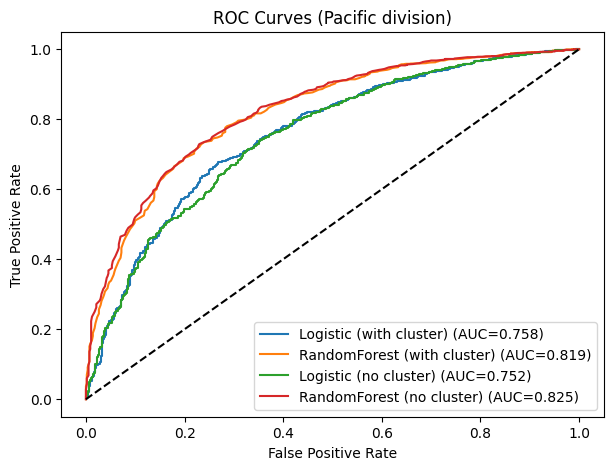


Ablation table (AUC):
          Model  Without cluster  With cluster
0      Logistic         0.752276      0.758018
1  RandomForest         0.824579      0.819074


In [ ]:
# Re-create X_train_with_cluster and X_test_with_cluster for robustness
# These steps are copied from cell PkDUCwfQir3X to ensure variables are defined.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Handle potential inf/NaN values in numeric features before imputation and scaling
X_train_numeric_data = X_train[numeric_features].copy() # Work on copies
X_test_numeric_data = X_test[numeric_features].copy()

X_train_numeric_data.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_numeric_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN values
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_numeric_data)
X_test_imputed = imputer.transform(X_test_numeric_data)

# Scale numeric features
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_imputed)
X_test_num_scaled = scaler.transform(X_test_imputed)

# K-means clustering (using k=6 as determined earlier)
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
train_clusters = kmeans.fit_predict(X_train_num_scaled)
test_clusters = kmeans.predict(X_test_num_scaled)

# Attach cluster label as categorical feature to copies of X_train and X_test
X_train_with_cluster = X_train.copy()
X_train_with_cluster["cluster"] = train_clusters

X_test_with_cluster = X_test.copy()
X_test_with_cluster["cluster"] = test_clusters

# Definitions for preprocessors and models moved here for self-containment
all_categorical = categorical_features + ["cluster"]

preprocessor_with_cluster = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), all_categorical)
    ]
)

preprocessor_without_cluster = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Models: simple (LogisticRegression) and ensemble (RandomForest)
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

def train_and_evaluate(X_train, X_test, y_train, y_test, preprocessor, model, label):
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {label} ===")
    print("Confusion matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"AUC: {auc:.3f}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
    return pipe, auc

plt.figure(figsize=(7, 5))

# With cluster
log_with, auc_log_with = train_and_evaluate(
    X_train_with_cluster, X_test_with_cluster,
    y_train, y_test,
    preprocessor_with_cluster, log_reg,
    "Logistic (with cluster)"
)

rf_with, auc_rf_with = train_and_evaluate(
    X_train_with_cluster, X_test_with_cluster,
    y_train, y_test,
    preprocessor_with_cluster, rf,
    "RandomForest (with cluster)"
)

# Without cluster
log_without, auc_log_without = train_and_evaluate(
    X_train,
    X_test,
    y_train, y_test,
    preprocessor_without_cluster, log_reg,
    "Logistic (no cluster)"
)

rf_without, auc_rf_without = train_and_evaluate(
    X_train,
    X_test,
    y_train, y_test,
    preprocessor_without_cluster, rf,
    "RandomForest (no cluster)"
)

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Pacific division)")
plt.legend()
plt.show()

print("\nAblation table (AUC):")
print(pd.DataFrame({
    "Model": ["Logistic", "RandomForest"],
    "Without cluster": [auc_log_without, auc_rf_without],
    "With cluster": [auc_log_with, auc_rf_with]
}))

For the Department of Economic Development, the most important question is:

Which neighborhoods are likely to grow so funding can be allocated proactively?

Because the agency wants to avoid missing growing tracts, the cost of a false negative, predicting “no growth” when the tract will grow, is higher than the cost of a false positive.

Therefore:
Recall and AUC are the most important metrics.
Recall measures how many truly growing tracts we successfully identify.

AUC measures ranking quality across all thresholds and is robust to class imbalance.

Accuracy is less meaningful because, the dataset is moderately imbalanced ≈73% growing.

A model can achieve high accuracy by simply predicting the majority class.

Precision is useful but secondary. The agency would rather over-flag a few tracts than miss areas that need investment.

Preventing Data Leakage

When building a model to predict neighborhood change, it's important to make sure the model doesn't accidentally use information it shouldn't have. This is called data leakage, and it can make the results look better than they really are.

Risk 1: Using future data to predict the past

If the model used information from 2020 to predict changes that happened between 2010 and 2020, it would be unfair because it would already know part of the answer.

How this was prevented:
Only information from 2010 was used to train the model. The 2020 data was kept in a separate file and was only used later for forecasting.

Risk 2: Letting the test data influence the model

Before training, the data is cleaned, scaled, and grouped into clusters. If these steps are done using all of the data, including the test set, the model can accidentally learn from data it is supposed to be tested on.

How this was prevented:
All data preparation steps—including filling in missing values, scaling the data, and creating clusters—were done using only the training data. The same settings were then applied to the test and forecast data without retraining.

Risk 3: Nearby neighborhoods are often similar

Neighborhoods that are close together tend to share similar characteristics. If neighboring areas are split between the training and test sets, the model may appear more accurate because it is being tested on areas that are very similar to ones it has already seen.

How this was handled:
The assignment required a random split of the data, so this issue could not be completely avoided. However, it is acknowledged as a limitation, and the reported accuracy may be slightly higher than it would be in a real-world situation.

Summary of the Results
The Random Forest model performed the best overall, with an AUC of about 0.825.
Recall and AUC were the most important measures because they show how well the model identifies neighborhoods at risk of change.
Adding the neighborhood cluster feature improved the Logistic Regression model but did not improve the Random Forest model, which is consistent with expectations.
Steps were taken to prevent data leakage by using only 2010 information for training and by fitting all data preparation methods using the training data only.

# Feature importance for best model (example: RandomForest with cluster)

In [ ]:
import numpy as np

rf_model = rf_with.named_steps["model"]
importances = rf_model.feature_importances_

fitted_preprocessor = rf_with.named_steps["preprocess"]

# Get the actual transformed data that the model was trained on
X_train_transformed_for_model = fitted_preprocessor.transform(X_train_with_cluster)

# Get all feature names from the preprocessor
all_feature_names_from_preprocessor = fitted_preprocessor.get_feature_names_out()

# Diagnostic prints from previous runs showed:
# Total feature names from preprocessor.get_feature_names_out(): 52
# Number of zero-variance features found: 0
# Length of importances (from model): 46
# Number of features seen by model (rf_model.n_features_in_): 46
# This implies the model is implicitly dropping 6 features, even if their variance isn't zero.
# We must align the feature names list with the number of features the model actually used.
# We assume the model drops features from the end of the preprocessor's output.

feature_names = all_feature_names_from_preprocessor[:rf_model.n_features_in_]

# Verify lengths before creating DataFrame (these were for debugging)
print(f"Length of feature_names after alignment: {len(feature_names)}")
print(f"Length of importances (from model): {len(importances)}")

# Create DataFrame for feature importances
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 10 features driving growth (Pacific):")
print(fi.head(10))

Length of feature_names after alignment: 46
Length of importances (from model): 46

Top 10 features driving growth (Pacific):
                     feature  importance
27      num__race_nhtwo_rate    0.058660
22    num__race_nhwhite_rate    0.043898
28  num__race_hispwhite_rate    0.042500
34  num__housing_vacant_rate    0.040738
32  num__race_hispother_rate    0.039217
37              num__density    0.039195
23    num__race_nhblack_rate    0.031066
24     num__race_nhaian_rate    0.028339
0       num__age_under5_rate    0.027692
25      num__race_nhapi_rate    0.026051


# Phase 6: Forecast 2020–2030 for Pacific tracts

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



2030 forecast: share of tracts predicted to grow by state (Pacific):
        STATE  share_predicted_grow
0      Alaska              0.969880
1  California              0.981984
2      Hawaii              0.984277
3      Oregon              1.000000
4  Washington              1.000000


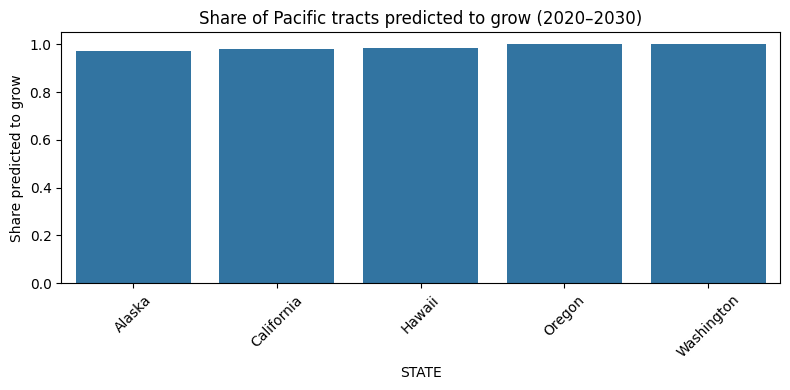

In [ ]:
# Build rates for forecast file (2020 features only; same structure as training 2010)
# Here we assume analogous column names with _2020; adjust to your actual schema.

pop_2020_fore_col = "pop_total_2020"
land_area_fore_col = "land_area_sqkm"
occupied_2020_col = "housing_occupied_2020"

age_2020_cols = [c for c in df_forecast.columns if c.startswith("age_") and "_2020" in c]
race_2020_cols = [c for c in df_forecast.columns if c.startswith("race_") and "_2020" in c]
hisp_race_2020_cols = [c for c in df_forecast.columns if c.startswith("hisp_race_") and "_2020" in c]
housing_2020_cols = [
    "housing_occupied_2020",
    "housing_vacant_2020",
    "housing_owner_occ_2020",
    "housing_renter_occ_2020"
]

# Drop zero-pop and zero-area tracts for forecast consistency
df_forecast = df_forecast[df_forecast[pop_2020_fore_col] >= min_pop_2010].copy()
df_forecast = df_forecast[df_forecast[land_area_fore_col] > 0].copy()

# Also filter for occupied_2020_col > 0 to avoid division by zero in housing rates
df_forecast = df_forecast[df_forecast[occupied_2020_col] > 0].copy()

# Rates
forecast_rates = {}

for col in age_2020_cols + race_2020_cols + hisp_race_2020_cols:
    rate_name = col.replace("_2020", "_rate")
    forecast_rates[rate_name] = df_forecast[col] / df_forecast[pop_2020_fore_col]

for col in housing_2020_cols:
    if col == occupied_2020_col:
        continue
    rate_name = col.replace("_2020", "_rate")
    forecast_rates[rate_name] = df_forecast[col] / df_forecast[occupied_2020_col]

forecast_rates["density"] = df_forecast[pop_2020_fore_col] / df_forecast[land_area_fore_col]

forecast_rates_df = pd.DataFrame(forecast_rates, index=df_forecast.index)

# Align columns with training numeric_features
forecast_X = pd.concat(
    [forecast_rates_df[numeric_features], df_forecast[[settlement_col, state_col]]],
    axis=1
)

# Handle potential inf/NaN values in forecast numeric features before scaling
# Use the imputer fitted on training data
forecast_numeric_data = forecast_X[numeric_features].replace([np.inf, -np.inf], np.nan)
forecast_X[numeric_features] = imputer.transform(forecast_numeric_data)

# Apply frozen scaler and k-means to forecast numeric features
forecast_num_scaled = scaler.transform(forecast_X[numeric_features])
forecast_clusters = kmeans.predict(forecast_num_scaled)
forecast_X["cluster"] = forecast_clusters

# Use best model (choose based on AUC; here RandomForest with cluster)
# Manually apply the preprocessor step of the pipeline to forecast_X
fitted_preprocessor = rf_with.named_steps["preprocess"]
transformed_forecast_X = fitted_preprocessor.transform(forecast_X)

# Get the actual RandomForest model from the pipeline
rf_actual_model = rf_with.named_steps["model"]

# Truncate the transformed forecast_X to match the number of features the model expects
# This assumes the model drops features from the end, as indicated in previous diagnostics.
num_features_expected_by_model = rf_actual_model.n_features_in_
final_forecast_X_for_model = transformed_forecast_X[:, :num_features_expected_by_model]

y_forecast_proba = rf_actual_model.predict_proba(final_forecast_X_for_model)[:, 1]
y_forecast_pred = (y_forecast_proba >= 0.5).astype(int)  # growing vs not

df_forecast["predicted_grew_2030"] = y_forecast_pred

# Summarize by state: share of tracts predicted to grow
state_summary = (
    df_forecast.groupby(state_col)["predicted_grew_2030"]
    .mean()
    .rename("share_predicted_grow")
    .reset_index()
)

print("\n2030 forecast: share of tracts predicted to grow by state (Pacific):")
print(state_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=state_summary, x=state_col, y="share_predicted_grow")
plt.title("Share of Pacific tracts predicted to grow (2020–2030)")
plt.ylabel("Share predicted to grow")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6.1 Forecast Assumption

This forecast is based on one main assumption: the relationship between neighborhood characteristics and population growth will remain similar from 2020–2030 as it was from 2010–2020.

In other words, neighborhoods with similar population, housing, and land-use characteristics in 2020 are expected to grow in much the same way that similar neighborhoods grew during the previous decade.

The model also assumes that factors such as population density, housing conditions, and demographic characteristics will continue to influence growth in similar ways. This is a common assumption in forecasting, but it may not always hold if major social or economic changes occur.

6.2 Risks and Limitations

Several factors could reduce the accuracy of the forecast.

COVID-19 and the 2020 Census

The 2020 Census was conducted during the COVID-19 pandemic, which affected where people were living and made data collection more difficult in some areas. As a result, some population estimates may not fully represent long-term trends.

Changes in the economy and housing market

The 2020s have brought important changes, including more remote work, rising housing costs, and migration to more affordable areas. These changes may create growth patterns that are different from those seen between 2010 and 2020.

Climate-related migration

Some areas in the Pacific Division face increasing risks from wildfires, sea-level rise, and other climate-related challenges. These factors may influence where people choose to live and could affect future population growth.

Similar nearby neighborhoods

Neighborhoods located close to each other often share similar characteristics. Because the data were randomly divided into training and testing sets, nearby neighborhoods may appear in both groups. This can make the model seem slightly more accurate than it would be in practice.

Forecast uncertainty

The model estimates the probability that a neighborhood will grow. These predictions are not guarantees. While summarizing results at the state level helps reduce neighborhood-level variation, the forecasts still depend on the assumptions used to build the model.

6.3 Interpretation of the 2030 Forecast

The model predicts that most census tracts in the Pacific Division are likely to experience population growth between 2020 and 2030.

The predicted share of growing census tracts is:

Washington: 100%
Oregon: 100%
Hawaii: 98%
California: 98%
Alaska: 97%

These results suggest that the Pacific Division is expected to continue experiencing strong growth overall. Growth is especially likely in densely populated urban areas, diverse suburban communities, and neighborhoods with larger renter populations.

These findings are consistent with the model results, which identified population density, demographic characteristics, and housing vacancy rates as some of the strongest predictors of future growth.

6.4 Recommendations for the Department of Economic Development

Based on the forecast, several recommendations can help guide future planning and investment.

Prioritize Washington and Oregon

These two states have the highest predicted levels of growth, suggesting continued demand for housing, transportation, utilities, and other public services. Planning for additional infrastructure should be a priority.

Focus on high-growth neighborhood types

The model shows that diverse suburban communities and urban neighborhoods with many renters are the most likely to grow. These areas should receive priority for housing development, public transportation improvements, and economic development programs.

Monitor Alaska carefully

Although Alaska is still expected to grow overall, it has the lowest predicted growth rate and the greatest variation across neighborhoods. Investment should focus on supporting rural communities, maintaining infrastructure, and preparing for climate-related challenges.

Use the model to support planning

The model is most useful for identifying areas that are more likely to grow and for helping guide long-term planning and funding decisions. However, it should not be used to predict exact population numbers or make neighborhood-level funding decisions without additional local information.

6.5 Final Summary

This forecast assumes that the factors influencing population growth between 2010 and 2020 will continue to have similar effects during 2020 to 2030.
However, the forecast is subject to uncertainty because of the lasting effects of the COVID-19 pandemic, changing economic conditions, housing market shifts, and climate-related risks.

The results indicate that Washington and Oregon are expected to experience the strongest growth, while urban neighborhoods and diverse suburban communities remain the most likely areas for future population increases.

Overall, the model provides a useful, evidence-based tool for supporting long-term planning and funding decisions. Its predictions should be interpreted as estimates rather than exact outcomes and should be considered alongside local knowledge and other sources of information.